In [171]:
import MDAnalysis as mda
import prolif as plf
from rdkit import Chem
import os
from collections import defaultdict
import pandas as pd
import sys
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
from decimal import Decimal
from rdkit.ML.Scoring.Scoring import CalcBEDROC
from scipy.integrate import trapezoid

# Loading and cleaning data

In [2]:
# Import all pickled IFP dictionaries from prolif_fps directory

IFP_pickles = [file for file in os.listdir('./prolif_fps') if file.endswith('.pkl')]

IFP_dicts = {}

for pickle in IFP_pickles:
    temp_dict = pd.read_pickle(f"./prolif_fps/{pickle}")
    key = list(temp_dict.keys())[0]
    IFP_dicts[key] = temp_dict[key]



# Clean up column levels

for run_key, run_dict in IFP_dicts.items():
    for conformer_key, conformer_dict in IFP_dicts[run_key].items():
        for ligand_key, ligand_list in IFP_dicts[run_key][conformer_key].items():
            # remove superfluous ligand columns level 
            ligand_list[1].columns = ligand_list[1].columns.droplevel("ligand")
            # merge protein and interaction column level
            ligand_list[1].columns = ligand_list[1].columns.map("_".join)
            if "_" in ligand_list[1].columns:
                ligand_list[1].rename(columns={'_': 'LigName'}, inplace=True)

## Summary stats of IFP counts, enrichments

In [3]:
IFP_frequencies = {}

for run_key, run_dict in IFP_dicts.items():
    IFP_frequencies[run_key] = {}

    for conformer_key, conformer_dict in IFP_dicts[run_key].items():

        ligand_keys = list(conformer_dict.keys())
        actives_key = [key for key in ligand_keys if key.endswith("true_actives.sdf")][0]
        inactives_key = [key for key in ligand_keys if key.endswith("true_inactives.sdf")][0]
        decoys_key = [key for key in ligand_keys if key.endswith("decoys.sdf")][0]

        actives = IFP_dicts[run_key][conformer_key][actives_key][1].copy()
        if 'LigName' in actives.columns:
            actives.drop('LigName', axis=1, inplace=True)
        freq_actives = actives.mean(axis=0)
        freq_actives.name = 'freq_actives'

        inactives = IFP_dicts[run_key][conformer_key][inactives_key][1].copy()
        if 'LigName' in inactives.columns:
            inactives.drop('LigName', axis=1, inplace=True)
        freq_inactives = inactives.mean(axis=0)
        freq_inactives.name = 'freq_inactives'

        decoys = IFP_dicts[run_key][conformer_key][decoys_key][1].copy()
        if 'LigName' in decoys.columns:
            decoys.drop('LigName', axis=1, inplace=True)
        freq_decoys = decoys.mean(axis=0)
        freq_decoys.name = 'freq_decoys'

        new_df = pd.concat(
            [
                freq_actives.rename("freq_actives"),
                freq_inactives.rename("freq_inactives"),
                freq_decoys.rename("freq_decoys"),

            ],
            axis = 1
        )

        new_df['ER_actives_decoys'] = new_df['freq_actives'] / new_df['freq_decoys']
        new_df['Log2_ER_actives_decoys'] = np.log2(new_df['ER_actives_decoys'])

        new_df['ER_actives_inactives'] = new_df['freq_actives'] / new_df['freq_inactives']
        new_df['Log2_ER_actives_inactives'] = np.log2(new_df['ER_actives_inactives'])
        
        IFP_frequencies[run_key][conformer_key] = new_df



In [5]:
IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf']

,freq_actives,freq_inactives,freq_decoys,ER_actives_decoys,Log2_ER_actives_decoys,ER_actives_inactives,Log2_ER_actives_inactives
LEU363.A_VdWContact,0.070175,0.059524,0.161109,0.435578,-1.198997,1.178947,0.237499
ASP366.A_Hydrophobic,0.192982,0.250000,0.372447,0.518148,-0.948565,0.771930,-0.373458
ASP366.A_VdWContact,0.333333,0.583333,0.711755,0.468326,-1.094415,0.571429,-0.807355
ILE369.A_Hydrophobic,0.245614,0.202381,0.190079,1.292167,0.369792,1.213622,0.279319
ILE369.A_VdWContact,0.438596,0.452381,0.493122,0.889428,-0.169051,0.969529,-0.044644
...,...,...,...,...,...,...,...
ARG545.B_Anionic,NaN,NaN,0.007712,NaN,NaN,NaN,NaN
ARG545.B_PiCation,NaN,NaN,0.008962,NaN,NaN,NaN,NaN
LYS547.B_Hydrophobic,NaN,NaN,0.005836,NaN,NaN,NaN,NaN
LYS547.B_Anionic,NaN,NaN,0.043977,NaN,NaN,NaN,NaN


In [6]:
df = IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf'].dropna()
df.sort_values(by='freq_actives', ascending=False).head()


,freq_actives,freq_inactives,freq_decoys,ER_actives_decoys,Log2_ER_actives_decoys,ER_actives_inactives,Log2_ER_actives_inactives
GLU543.B_VdWContact,0.982456,0.928571,0.871822,1.126900,0.172360,1.058030,0.081380
GLU543.A_VdWContact,0.982456,0.940476,0.895790,1.096748,0.133233,1.044637,0.063002
GLU543.A_Hydrophobic,0.947368,0.785714,0.547937,1.728974,0.789917,1.205742,0.269921
GLU543.B_Hydrophobic,0.947368,0.928571,0.696332,1.360513,0.444151,1.020243,0.028913
HIS456.B_VdWContact,0.736842,0.571429,0.445602,1.653587,0.725599,1.289474,0.366782


## Binary Logistic regression model to find IFP weights

In [4]:
montpellier_ligand_data = pd.read_csv("./results/montpellier_ligands.csv")
true_actives = montpellier_ligand_data[montpellier_ligand_data["ACTIVE_LABEL"] == True]["ID"].tolist()
#true_actives_ligand_names = true_actives["ID"].tolist()

# 4H2I_C_4

actives_docking_4h2i_c_4 = pd.read_csv("./results/12Jun_rg/all_montpellier_4h2i_c_4_dimer.csv")[["LigName", "docking_score"]]
actives_docking_4h2i_c_4 = actives_docking_4h2i_c_4[actives_docking_4h2i_c_4["LigName"].isin(true_actives)]

actives_4h2i_c_4 = IFP_dicts['12Jun_rg']['4h2i_c_4_dimer_sdf']['4h2i_c_4_dimer_true_actives.sdf'][1]
actives_4h2i_c_4['Active'] = True
actives_4h2i_c_4 = actives_4h2i_c_4.merge(actives_docking_4h2i_c_4, on="LigName")

decoys_docking_4h2i_c_4 = pd.read_csv("./results/12Jun_rg/all_decoys_4h2i_c_4_dimer.csv")[["LigName", "docking_score"]]
decoys_4h2i_c_4 = IFP_dicts['12Jun_rg']['4h2i_c_4_dimer_sdf']['4h2i_c_4_dimer_decoys.sdf'][1]
decoys_4h2i_c_4['Active'] = False
decoys_4h2i_c_4 = decoys_4h2i_c_4.merge(decoys_docking_4h2i_c_4, on="LigName")

# 6TVE_C_1

actives_docking_6tve_c_1 = pd.read_csv("./results/12Jun_rg/all_montpellier_6tve_c_1_dimer.csv")[["LigName", "docking_score"]]
actives_docking_6tve_c_1 = actives_docking_6tve_c_1[actives_docking_6tve_c_1["LigName"].isin(true_actives)]

actives_6tve_c_1 = IFP_dicts['12Jun_rg']['6tve_c_1_dimer_sdf']['6tve_c_1_dimer_true_actives.sdf'][1]
actives_6tve_c_1['Active'] = True
actives_6tve_c_1 = actives_6tve_c_1.merge(actives_docking_6tve_c_1, on="LigName")

decoys_docking_6tve_c_1 = pd.read_csv("./results/12Jun_rg/all_decoys_6tve_c_1_dimer.csv")[["LigName", "docking_score"]]
decoys_6tve_c_1 = IFP_dicts['12Jun_rg']['6tve_c_1_dimer_sdf']['6tve_c_1_dimer_decoys.sdf'][1]
decoys_6tve_c_1['Active'] = False
decoys_6tve_c_1 = decoys_6tve_c_1.merge(decoys_docking_6tve_c_1, on="LigName")

# 6TVE_C_2

actives_docking_6tve_c_2 = pd.read_csv("./results/12Jun_rg/all_montpellier_6tve_c_2_dimer.csv")[["LigName", "docking_score"]]
actives_docking_6tve_c_2 = actives_docking_6tve_c_2[actives_docking_6tve_c_2["LigName"].isin(true_actives)]

actives_6tve_c_2 = IFP_dicts['12Jun_rg']['6tve_c_2_dimer_sdf']['6tve_c_2_dimer_true_actives.sdf'][1]
actives_6tve_c_2['Active'] = True
actives_6tve_c_2 = actives_6tve_c_2.merge(actives_docking_6tve_c_2, on="LigName")

decoys_docking_6tve_c_2 = pd.read_csv("./results/12Jun_rg/all_decoys_6tve_c_2_dimer.csv")[["LigName", "docking_score"]]
decoys_6tve_c_2 = IFP_dicts['12Jun_rg']['6tve_c_2_dimer_sdf']['6tve_c_2_dimer_decoys.sdf'][1]
decoys_6tve_c_2['Active'] = False
decoys_6tve_c_2 = decoys_6tve_c_2.merge(decoys_docking_6tve_c_1, on="LigName")


## 4H2I_C_4

### Only IFPs

In [19]:
print(f"shape actives: {actives_4h2i_c_4.shape}")
print(f"shape decoys: {decoys_4h2i_c_4.shape}")

# Check if all IFP columns in actives are present in decoys
set_a = set(actives_4h2i_c_4.columns)
set_d = set(decoys_4h2i_c_4.columns)

both = set_a.intersection(set_d)
print(f"All IFP columns in 'active' present in 'decoy': {set_a == both}")

d_not_a = set_d ^ set_a
print(f"Number of IFP columns in 'decoy' not present in 'active': {len(d_not_a)}")

decoys_4h2i_c_4_not_active = decoys_4h2i_c_4.drop(columns=d_not_a)
print(f"Shape decoys after removing columns not present in 'active': {decoys_4h2i_c_4_not_active.shape}")

all_4h2i_c_4 = pd.concat([actives_4h2i_c_4, decoys_4h2i_c_4_not_active])
print(f"Shape of combined df: {all_4h2i_c_4.shape}")

X_DOCKING = all_4h2i_c_4[["docking_score"]]
X_IFP = all_4h2i_c_4.drop(columns=["Active", "LigName", "docking_score"])
X_IFP_DOCKING_SCORE = all_4h2i_c_4.drop(columns=["Active", "LigName"])
Y = all_4h2i_c_4["Active"]

shape actives: (57, 67)
shape decoys: (4798, 191)
All IFP columns in 'active' present in 'decoy': True
Number of IFP columns in 'decoy' not present in 'active': 124
Shape decoys after removing columns not present in 'active': (4798, 67)
Shape of combined df: (4855, 67)


## Hyperparameter tuning with cross validation to pick regularization strength (C)
- Choose C
- Fit logistic regression
- Estimate performance with CV
- Compare models

It can be seen that the best regularization C is 0.01 (AUC 0.900894). 

In [197]:
def enrichment_factor(df: pd.DataFrame, fraction: float) -> float:
    df = df.sort_values("score", ascending=False)

    n_total = len(df)
    n_top = max(1, int(np.ceil(n_total * fraction)))


    n_actives = df["active"].sum()
    n_actives_in_top = df.head(n_top)["active"].sum()

    return (
        (n_actives_in_top / n_top)
        /
        (n_actives / n_total)
    )

def bedroc(df: pd.DataFrame, col: int, alpha: float) -> float:
    bedroc = CalcBEDROC(
        list(zip(df["score"], df["active"])),
        col=col,
        alpha=alpha
    )
    return bedroc


def auc(df: pd.DataFrame) -> float:
    ...


# def log_auc(df: pd.DataFrame) -> float:
#     # constants
#     LOGAUC_MAX = 1.0
#     LOGAUC_MIN = 0.001
#     RANDOM_LOGAUC = (
#         (LOGAUC_MAX - LOGAUC_MIN)
#         / np.log(10)
#         / np.log10(LOGAUC_MAX / LOGAUC_MIN)
#     )

#     # ROC curve (fractions 0–1)
#     fpr, tpr, _ = roc_curve(df["active"], df["score"])

#     # Convert to percentages to match the original implementation
#     points = np.column_stack((fpr * 100, tpr * 100))

#     # Keep only the desired FPR range
#     npoints = []
#     for x in points:
#         if LOGAUC_MIN * 100 <= x[0] <= LOGAUC_MAX * 100:
#             npoints.append([x[0] / 100, x[1] / 100])

#     area = 0.0
#     for point2, point1 in zip(npoints[1:], npoints[:-1]):
#         if point2[0] - point1[0] < 1e-6:
#             continue

#         dx = point2[0] - point1[0]
#         dy = point2[1] - point1[1]

#         intercept = point2[1] - dy / dx * point2[0]

#         area += (
#             dy / np.log(10)
#             + intercept * (np.log10(point2[0]) - np.log10(point1[0]))
#         )

#     return area / np.log10(LOGAUC_MAX / LOGAUC_MIN) - RANDOM_LOGAUC

import numpy as np
from scipy.integrate import trapezoid
from sklearn.metrics import roc_curve


def log_auc2(
    y_true,
    y_score,
    min_fpr=0.001,
):
    """
    Compute normalized logAUC with the random baseline subtracted.

    Parameters
    ----------
    y_true : array-like
        Binary activity labels (0/1 or False/True).

    y_score : array-like
        Prediction scores (higher = more likely active).

    min_fpr : float, default=0.001
        Lower FPR limit for integration.

    Returns
    -------
    float
        logAUC - random logAUC.
    """

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_score)

    # Remove duplicate FPR values (keep the highest TPR)
    fpr, unique_idx = np.unique(fpr, return_index=True)
    tpr = tpr[unique_idx]

    # Interpolate TPR at min_fpr if needed
    if min_fpr not in fpr:

        if min_fpr < fpr[0]:
            tpr_min = tpr[0]

        else:
            tpr_min = np.interp(min_fpr, fpr, tpr)

        fpr = np.insert(fpr, np.searchsorted(fpr, min_fpr), min_fpr)
        tpr = np.insert(tpr, np.searchsorted(fpr, min_fpr), tpr_min)

    # Restrict integration region
    mask = fpr >= min_fpr
    fpr = fpr[mask]
    tpr = tpr[mask]

    # Integrate on log10(FPR)
    area = trapezoid(
        y=tpr,
        x=np.log10(fpr)
    )

    # Normalize to [0, 1]
    area /= np.log10(1 / min_fpr)

    # Random baseline
    random = (
        (1 - min_fpr)
        / (np.log(10) * np.log10(1 / min_fpr))
    )

    return area - random


In [204]:
Cs = np.logspace(-3, 3, 13)
Cs = [float(C) for C in Cs]

results = []
coef_results = {}

for C in Cs:
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        class_weight="balanced"
    )
    
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    
    Y_true = []
    Y_pred = []
    coefs = []
    
    for train_idx, test_idx in cv.split(X_IFP_DOCKING_SCORE, Y):
        clf.fit(X_IFP_DOCKING_SCORE.iloc[train_idx], Y.iloc[train_idx])
        coefs.append(clf.coef_[0])
        p = clf.predict_proba(X_IFP_DOCKING_SCORE.iloc[test_idx])[:,1]
        Y_true.extend(Y.iloc[test_idx])
        Y_pred.extend(p)
    
    ranking = pd.DataFrame({
        "active": Y_true,
        "score": Y_pred
    }).sort_values("score", ascending=False)


    results.append({
        "C": C,
        "AUC": roc_auc_score(ranking["active"], ranking["score"]),
        "logAUC": log_auc2(ranking["active"], ranking["score"]),
        "EF1%": enrichment_factor(df=ranking, fraction=0.01),
        "EF0.1%": enrichment_factor(df=ranking, fraction=0.001),
        "BEDROC_80": bedroc(df=ranking, col=1, alpha=80),
    })


    coef_results[C] = pd.DataFrame({
        "label": X_IFP_DOCKING_SCORE.columns,
        "coefs": np.mean(coefs, axis=0),
        "coef_mean": np.mean(coefs, axis=0),
        "coef_sd": np.std(coefs, axis=0),
        "coef_mean/sd": np.mean(coefs, axis=0) / np.std(coefs, axis=0),
        "coefs_norm": np.linalg.norm(np.mean(coefs, axis=0)),
        "coefs_max": np.max(np.abs(np.mean(coefs, axis=0))),
    }).sort_values(by="coef_mean/sd", ascending=False)

results_df = pd.DataFrame(results)
results_df

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.868008,0.274190,13.906194,34.070175,0.216292
1,0.003162,0.881215,0.315000,15.644468,17.035088,0.289650
2,0.010000,0.887852,0.337878,19.121017,34.070175,0.330121
3,0.031623,0.885135,0.342977,19.121017,34.070175,0.337383
4,0.100000,0.875690,0.330264,20.859291,34.070175,0.325207
5,0.316228,0.861945,0.320596,20.859291,34.070175,0.307734
6,1.000000,0.845030,0.301427,19.121017,34.070175,0.288342
7,3.162278,0.835403,0.287184,17.382743,34.070175,0.272116
8,10.000000,0.825212,0.277673,17.382743,34.070175,0.269104
9,31.622777,0.816327,0.270023,17.382743,17.035088,0.260548


In [202]:
results_df

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.881361,0.287300,13.906194,17.035088,0.242037
1,0.003162,0.894276,0.318667,17.382743,17.035088,0.294365
2,0.010000,0.900894,0.338647,19.121017,17.035088,0.323837
3,0.031623,0.898053,0.348848,19.121017,17.035088,0.331366
4,0.100000,0.887775,0.338880,19.121017,34.070175,0.316502
5,0.316228,0.872487,0.317827,19.121017,34.070175,0.297141
6,1.000000,0.852727,0.294436,19.121017,34.070175,0.277894
7,3.162278,0.828595,0.272271,15.644468,34.070175,0.263081
8,10.000000,0.804710,0.252873,13.906194,34.070175,0.245926
9,31.622777,0.785057,0.239656,15.644468,34.070175,0.237954


In [109]:
print(coef_results.keys())
coef_results[0.01]


dict_keys([0.001, 0.0031622776601683794, 0.01, 0.03162277660168379, 0.1, 0.31622776601683794, 1.0, 3.1622776601683795, 10.0, 31.622776601683793, 100.0, 316.22776601683796, 1000.0])


,label,coefs,coef_mean,coef_sd,coef_mean/sd,coefs_norm,coefs_max
41,HIS456.B_PiStacking,0.895814,0.895814,0.076166,11.761334,2.339262,0.895814
11,HIS456.A_PiStacking,0.551794,0.551794,0.053168,10.378316,2.339262,0.895814
33,ARG545.A_Hydrophobic,0.781132,0.781132,0.077502,10.078863,2.339262,0.895814
29,GLU543.A_Hydrophobic,0.738276,0.738276,0.086458,8.539157,2.339262,0.895814
60,GLU543.B_Hydrophobic,0.323119,0.323119,0.051983,6.215902,2.339262,0.895814
...,...,...,...,...,...,...,...
2,ASP366.A_VdWContact,-0.509393,-0.509393,0.063278,-8.050096,2.339262,0.895814
30,GLU543.A_Cationic,-0.427721,-0.427721,0.048196,-8.874679,2.339262,0.895814
21,TYR531.A_VdWContact,-0.537915,-0.537915,0.056510,-9.518961,2.339262,0.895814
51,TYR531.B_VdWContact,-0.334934,-0.334934,0.028194,-11.879448,2.339262,0.895814


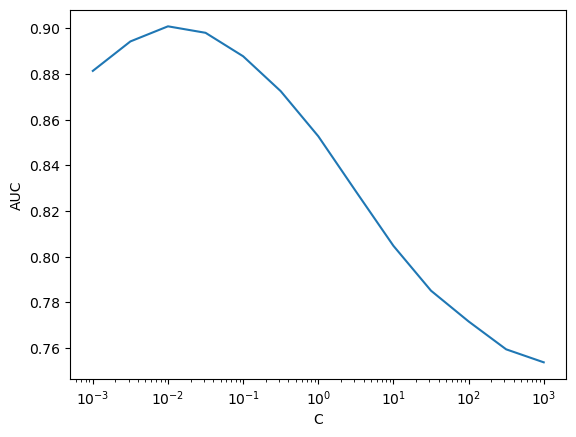

In [110]:
plt.plot([r["C"] for r in results], [r["AUC"] for r in results])
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("AUC")
plt.show()

In [35]:
clf = LogisticRegression(
    penalty="l2",
    C=0.1,
    solver="lbfgs",
    #class_weight="balanced"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

# cv = RepeatedStratifiedKFold(
#     n_splits=5,
#     n_repeats=10,
#     random_state=42
# )
coefs = []
Y_true = []
Y_pred = []

for train_idx, test_idx in cv.split(X_IFP, Y):
    clf.fit(X_IFP.iloc[train_idx], Y.iloc[train_idx])
    coefs.append(clf.coef_[0])
    p = clf.predict_proba(X_IFP.iloc[test_idx])[:,1]
    Y_true.extend(Y.iloc[test_idx])
    Y_pred.extend(p)

coefs = np.vstack(coefs)
coef_mean = coefs.mean(axis=0)
coef_sd = coefs.std(axis=0)

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

clf = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 13),
    cv=5,
    penalty="l2",
    scoring="roc_auc",
    max_iter=5000,
)


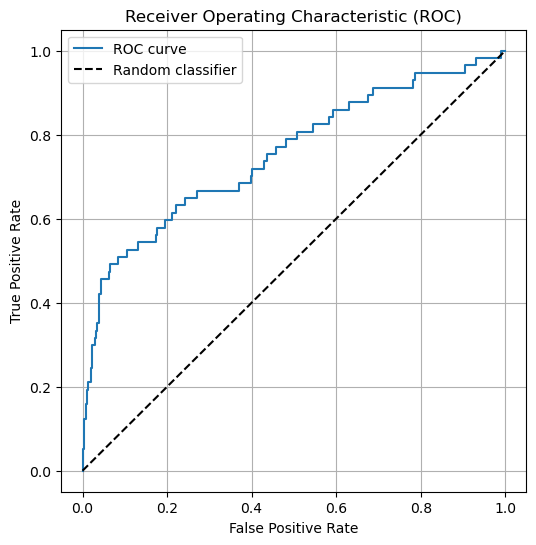

ROC AUC Score: 0.7536656355352743


In [196]:
# Cross validated ROC AUC -> How well will the model perform on unseen ligands 
fpr, tpr, thresholds = roc_curve(ranking["active"], ranking["score"])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)

plt.show()

print(f"ROC AUC Score: {roc_auc_score(Y_true, Y_pred)}")



/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simpl

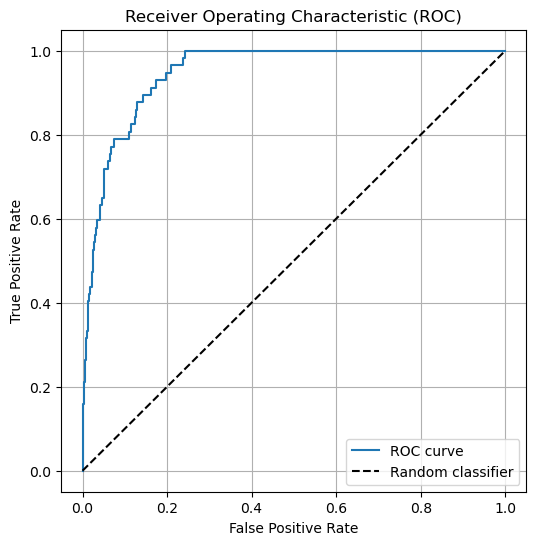

Training ROC AUC Score: 0.9478766737602656


In [38]:
# Training ROC AUC -> How well will the model perform on the training set (overfitting)
clf.fit(X_IFP, Y)

fpr, tpr, thresholds = roc_curve(Y, clf.predict_proba(X_IFP)[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)

plt.show()


train_auc = roc_auc_score(Y, clf.predict_proba(X_IFP)[:, 1])
print(f"Training ROC AUC Score: {train_auc}")

In [71]:
IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf']

NameError: name 'IFP_frequencies' is not defined

In [69]:
len(X.columns)

64

In [66]:
len(coef_mean)

64

In [65]:
coef_sd

array([0.12522606, 0.13866201, 0.10697918, 0.19564551, 0.17239743,
       0.1594048 , 0.30053954, 0.17028525, 0.10754288, 0.17396498,
       0.12994789, 0.14610517, 0.24760975, 0.14978595, 0.17143163,
       0.11482356, 0.33071363, 0.11932494, 0.17868824, 0.10923563,
       0.17924229, 0.18446152, 0.24798245, 0.12308302, 0.20019336,
       0.35228216, 0.2935391 , 0.13953994, 0.2482597 , 0.18144483,
       0.23109602, 0.21188133, 0.18413333, 0.19279504, 0.18974891,
       0.03718073, 0.23491889, 0.21625226, 0.25712117, 0.30173114,
       0.27802028, 0.14926469, 0.1715406 , 0.28110543, 0.16535252,
       0.19412527, 0.26063533, 0.17002502, 0.37578997, 0.07173096,
       0.20511093, 0.17103723, 0.21796989, 0.2447861 , 0.24481381,
       0.16848882, 0.09992842, 0.17204706, 0.07061262, 0.30356423,
       0.15843287, 0.18943656, 0.19153148, 0.14838314])

## Include IFP and docking scores

In [ ]:
IFP_dicts['12Jun_rg']['4h2i_c_1_dimer_sdf']['4h2i_c_1_dimer_true_actives.sdf'][1].columns